# Reported result surfaces and their limits

This notebook connects the computed outcomes to the research questions and result
tables. It uses the same evaluation functions and bound inputs as the assessment
notebooks. The RFC section uses saved public retrieval; the other default tables and plots
use illustrative inputs. Accepted private inputs keep
their own revision and relevance pools in an ignored executed copy.

Use the main environment including the `evaluation` extra. No model requests are
made. See thesis Sections 3.1–3.5, Appendix E and Chapter 4.

In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from tabulate import tabulate

from rag_comparison import config
from rag_comparison.artifacts import read_jsonl, verify_artifacts
from rag_comparison.evaluation import (
    connected_components,
    paired_intervention_change,
    paired_system_gap_shift,
)
from rag_comparison.metrics import score_question
from rag_comparison.evaluation import outcome_inputs
from rag_comparison.artifacts import write_analysis_manifest

## Select the data and retain its result basis

PRIMARY and FINAL require their full matching shared qrels pools. FINAL also
retains C-EMBED for the reported C-EMBED versus C-FINAL comparison. Its pool is
not replaced by PRIMARY qrels. Question identity and accepted review status bind
the scalar rows; ordinal grade means and a combined quality score are not computed.

In [2]:
data_dir = Path("../examples/evaluation")
output_dir = Path("../local/evaluation/reported_example")
manifest = json.loads((data_dir / "manifest.json").read_text(encoding="utf-8"))
metadata = manifest["metadata"]
assert metadata["dataset_kind"] in ("illustrative", "accepted")
paths = verify_artifacts(data_dir, manifest)
questions = read_jsonl(paths["questions"])
references = read_jsonl(paths["references"])
rankings = read_jsonl(paths["retrieval"])
outcomes = read_jsonl(paths["outcomes"])
inventory = read_jsonl(paths["graph_inventory"])
if metadata["dataset_kind"] == "accepted":
    assert data_dir.resolve().is_relative_to(Path("../local").resolve())
print(
    {
        "dataset_kind": metadata["dataset_kind"],
        "scopes": metadata["scopes"],
        "revision": metadata["review_revision_ids"],
    }
)

{'dataset_kind': 'illustrative', 'scopes': ['PRIMARY', 'FINAL'], 'revision': {'PRIMARY': 'EXAMPLE-REVIEW-PRIMARY', 'FINAL': 'EXAMPLE-REVIEW-FINAL', 'GU': 'EXAMPLE-REVIEW-GU'}}


## Recalculate retrieval from native evidence positions

Projection preserves physical rank positions, including duplicates and failures.
The shared pool defines IDCG for each scope. Only fully judged cases with positive
IDCG are valid. A partial diagnostic score cannot become an aggregate input.
Both retrieval outcomes use the same valid case basis.

A saved invalid case may retain its diagnostic partial score. Its validity status excludes it from every aggregate and pair selection.

In [3]:
reference_by_key = {(row["scope"], row["question_id"]): row for row in references}
saved_by_key = {
    (row["scope"], row["condition_id"], row["question_id"], row["metric"]): row
    for row in outcomes
}
assert len(saved_by_key) == len(outcomes)
retrieval_checks = 0
for ranking in rankings:
    reference = reference_by_key[(ranking["scope"], ranking["question_id"])]
    if not reference["qrels"]:
        continue
    result = score_question(
        ranking["ranked_units"],
        reference["qrels"],
        [set(group) for group in reference["minimal_evidence_sets"]],
    )
    valid = result["metric_validity_status"] == "fully_judged" and result["idcg"] > 0
    for metric, field in (
        ("ndcg_at_5", "ndcg_at_k"),
        ("evidence_recall_at_5", "evidence_recall_at_k"),
    ):
        expected = saved_by_key[
            (ranking["scope"], ranking["condition_id"], ranking["question_id"], metric)
        ]
        assert (expected["status"] == "valid") == valid
        if valid or expected["value"] is not None:
            assert expected["value"] == result[field]
        retrieval_checks += 1
print({"checked_retrieval_outcomes": retrieval_checks})

{'checked_retrieval_outcomes': 576}


## Public RFC baseline retrieval

Run notebook 05 first. Its bound results use the saved Azure rankings and RFC
reference grades. Three answerable questions give case-level differences and
counts only; answer-quality grades and configuration variants remain illustrative.


In [4]:
public_rfc_baseline = None
if data_dir.resolve() == Path("../examples/evaluation").resolve():
    public_metric_dir = Path("../local/evaluation/rfc2795_retrieval")
    public_manifest = json.loads(
        (public_metric_dir / "analysis_manifest.json").read_text(encoding="utf-8")
    )
    public_paths = verify_artifacts(public_metric_dir, public_manifest)
    public_metrics = json.loads(
        public_paths["rfc_retrieval"].read_text(encoding="utf-8")
    )
    assert public_metrics["dataset_kind"] == "saved_rfc_results"
    verify_artifacts(Path(".."), {"artifacts": public_metrics["source_bindings"]})
    records = public_metrics["outcomes"]
    question_ids = sorted(
        {row["question_id"] for row in records if row["cohort"] == "A"}
    )
    states = {
        condition: {
            row["question_id"]: row["ndcg_at_5"]
            for row in records
            if row["condition_id"] == condition
        }
        for condition in ("C0", "G0")
    }
    public_rfc_baseline = {
        "dataset_kind": "saved_rfc_results",
        "source_bindings": public_metrics["source_bindings"],
        "result": paired_intervention_change(
            states["C0"],
            states["G0"],
            question_ids=question_ids,
            scale=config.OUTCOME_SCALES["ndcg_at_5"],
            cluster_by_question=connected_components(
                {
                    question_id: set(units)
                    for question_id, units in public_metrics["question_units"].items()
                }
            ),
        ),
    }
    result = public_rfc_baseline["result"]
    display(
        Markdown(
            tabulate(
                [
                    (
                        question_id,
                        states["C0"][question_id],
                        states["G0"][question_id],
                        difference,
                    )
                    for question_id, difference in result["question_changes"].items()
                ],
                headers=["RFC question", "C0 nDCG@5", "G0 nDCG@5", "G0 minus C0"],
                tablefmt="github",
                floatfmt=".6f",
            )
        )
    )
    print({"paired_cases": result["k"], "aggregation": result["aggregation_status"]})


| RFC question    |   C0 nDCG@5 |   G0 nDCG@5 |   G0 minus C0 |
|-----------------|-------------|-------------|---------------|
| DEMO-IMPS-Q-001 |    0.825402 |    0.887915 |      0.062513 |
| DEMO-IMPS-Q-002 |    0.851630 |    1.000000 |      0.148370 |
| DEMO-IMPS-Q-003 |    0.902024 |    1.000000 |      0.097976 |

{'paired_cases': 3, 'aggregation': 'count_only_k_below_20'}


## Research-question and result mapping

The mapping connects each research question to its calculation, input basis and
thesis result table. The illustrative dataset demonstrates those calculations;
it does not contain the private corpus findings.

In [5]:
result_map = [
    (
        "RQ1 / baseline",
        "3.2, Tables 7–8",
        "PRIMARY C0/G0",
        "Paired retrieval, ordinal grades and behaviour",
    ),
    (
        "RQ2 / graph and errors",
        "3.3, Tables 9–10",
        "Fixed graph and diagnosis inputs",
        "Sample categories, provenance and own error denominators",
    ),
    (
        "RQ3 / one factor",
        "3.4.1, Tables 11–13",
        "PRIMARY",
        "Each variant against its architecture baseline",
    ),
    (
        "FINAL",
        "3.4.2, Tables 14–15",
        "FINAL and supplemental C-EMBED",
        "Combined conditions and baseline gaps on the FINAL pool",
    ),
    (
        "Genuine User",
        "3.5, Table 16",
        "Separate nominal review",
        "Category distributions and paired transitions",
    ),
]
display(
    Markdown(
        tabulate(
            result_map,
            headers=["Surface", "Thesis reference", "Input basis", "Calculation"],
            tablefmt="github",
        )
    )
)

| Surface                | Thesis reference    | Input basis                      | Calculation                                              |
|------------------------|---------------------|----------------------------------|----------------------------------------------------------|
| RQ1 / baseline         | 3.2, Tables 7–8     | PRIMARY C0/G0                    | Paired retrieval, ordinal grades and behaviour           |
| RQ2 / graph and errors | 3.3, Tables 9–10    | Fixed graph and diagnosis inputs | Sample categories, provenance and own error denominators |
| RQ3 / one factor       | 3.4.1, Tables 11–13 | PRIMARY                          | Each variant against its architecture baseline           |
| FINAL                  | 3.4.2, Tables 14–15 | FINAL and supplemental C-EMBED   | Combined conditions and baseline gaps on the FINAL pool  |
| Genuine User           | 3.5, Table 16       | Separate nominal review          | Category distributions and paired transitions            |

## Baseline, intervention and FINAL contrasts

Every row uses its own complete question pairs. Positive ordinal effects mean
more wins than losses; ties remain in k. Numeric effects are paired differences.
The G-only ENTITY gap holds C0 fixed. The supplemental FINAL comparison assesses
C-FINAL relative to C-EMBED using the FINAL pool.

For Table 15's C-FINAL versus G-FINAL contrast, C-FINAL is the variant and G-FINAL is the reference: positive dominance favours C-FINAL. The symmetric gap retains its separately defined G−C direction.

In [6]:
rows_by_scope = {
    scope: [row for row in outcomes if row["scope"] == scope]
    for scope in metadata["scopes"]
}
clusters_by_scope = {
    scope: connected_components(
        {
            row["question_id"]: set(row["question_units"])
            for row in references
            if row["scope"] == scope
        }
    )
    for scope in metadata["scopes"]
}
target_ids = {
    metric: [
        q["question_id"]
        for q in questions
        if metric == "correct_behavior" or q["cohort"] == "A"
    ]
    for metric in config.OUTCOME_SCALES
}
contrast_jobs = []
for scope in metadata["scopes"]:
    comparisons = [("C0", "G0")]
    if scope == "PRIMARY":
        comparisons += [
            (config.CONDITIONS[cid]["system"] + "0", cid)
            for cid in metadata["conditions_by_scope"][scope]
            if cid not in ("C0", "G0")
        ]
    else:
        comparisons += [
            ("C0", "C-FINAL"),
            ("G0", "G-FINAL"),
            ("G-FINAL", "C-FINAL"),
            ("C-EMBED-LARGE-1536", "C-FINAL"),
        ]
    for left, right in comparisons:
        for metric in config.OUTCOME_SCALES:
            contrast_jobs.append((scope, left, right, metric))

In [7]:
contrasts = []
for scope, left, right, metric in contrast_jobs:
    ids = target_ids[metric]
    values, na = outcome_inputs(rows_by_scope[scope], (left, right), metric, ids)
    result = paired_intervention_change(
        values[left],
        values[right],
        question_ids=ids,
        scale=config.OUTCOME_SCALES[metric],
        cluster_by_question=clusters_by_scope[scope],
        non_applicable_question_ids=na,
    )
    contrasts.append(
        {
            "scope": scope,
            "reference": left,
            "variant": right,
            "metric": metric,
            "result": result,
        }
    )

In [8]:
contrast_rows = [
    (
        row["scope"],
        row["reference"],
        row["variant"],
        row["metric"],
        row["result"]["N_app"],
        row["result"]["k"],
        row["result"]["standard"]["estimate"] if row["result"]["standard"] else None,
    )
    for row in contrasts
]
display(
    Markdown(
        tabulate(
            contrast_rows[:8],
            headers=[
                "Scope",
                "Reference",
                "Variant",
                "Outcome",
                "N_app",
                "k",
                "Paired effect",
            ],
            tablefmt="github",
        )
    )
)

| Scope   | Reference   | Variant              | Outcome              |   N_app |   k |   Paired effect |
|---------|-------------|----------------------|----------------------|---------|-----|-----------------|
| PRIMARY | C0          | G0                   | ndcg_at_5            |      24 |  22 |       0.167024  |
| PRIMARY | C0          | G0                   | evidence_recall_at_5 |      24 |  22 |       0         |
| PRIMARY | C0          | G0                   | answer_correctness   |      24 |  23 |       0.478261  |
| PRIMARY | C0          | G0                   | faithfulness         |      23 |  22 |       0.454545  |
| PRIMARY | C0          | G0                   | citation_correctness |      23 |  22 |      -0.454545  |
| PRIMARY | C0          | G0                   | correct_behavior     |      28 |  27 |       0.0740741 |
| PRIMARY | C0          | C-CHUNK-STRUCT-800-0 | ndcg_at_5            |      24 |  24 |       0.016535  |
| PRIMARY | C0          | C-CHUNK-STRUCT-800-0 | evidence_recall_at_5 |      24 |  24 |       0         |

## Symmetric gap changes require four states

Four-state pairing avoids subtracting aggregates computed on different populations.
For ordinal outcomes, each architecture gap is a sign before its change is formed.
The resulting signed change can range from −2 to 2. A G-only intervention uses
C0 in both Classical states; FINAL retains its own outcome basis.

In [9]:
gap_states = [
    ("PRIMARY", "C-CHUNK-STRUCT-800-0", "G-CHUNK-STRUCT-800-0"),
    ("PRIMARY", "C-EMBED-LARGE-1536", "G-EMBED-LARGE-1536"),
    ("PRIMARY", "C0", "G-ENTITY-POLICY-PROCESS-ROLE"),
    ("FINAL", "C-FINAL", "G-FINAL"),
]

In [10]:
gaps = []
for scope, c_variant, g_variant in gap_states:
    for metric in ("ndcg_at_5", "answer_correctness", "correct_behavior"):
        state_ids = ("C0", "G0", c_variant, g_variant)
        ids = target_ids[metric]
        values, na = outcome_inputs(rows_by_scope[scope], state_ids, metric, ids)
        result = paired_system_gap_shift(
            *(values[cid] for cid in state_ids),
            question_ids=ids,
            scale=config.OUTCOME_SCALES[metric],
            cluster_by_question=clusters_by_scope[scope],
            non_applicable_question_ids=na,
        )
        gaps.append(
            {
                "scope": scope,
                "c_variant": c_variant,
                "g_variant": g_variant,
                "metric": metric,
                "result": result,
            }
        )

In [11]:
gap_rows = [
    (
        row["scope"],
        row["c_variant"],
        row["g_variant"],
        row["metric"],
        row["result"]["k_gap"],
        row["result"]["standard"]["estimate"] if row["result"]["standard"] else None,
    )
    for row in gaps
]
display(
    Markdown(
        tabulate(
            gap_rows,
            headers=[
                "Scope",
                "C variant",
                "G variant",
                "Outcome",
                "k_gap",
                "Gap shift",
            ],
            tablefmt="github",
        )
    )
)

| Scope   | C variant            | G variant                    | Outcome            |   k_gap |   Gap shift |
|---------|----------------------|------------------------------|--------------------|---------|-------------|
| PRIMARY | C-CHUNK-STRUCT-800-0 | G-CHUNK-STRUCT-800-0         | ndcg_at_5          |      22 |   0.014694  |
| PRIMARY | C-CHUNK-STRUCT-800-0 | G-CHUNK-STRUCT-800-0         | answer_correctness |      23 |   0         |
| PRIMARY | C-CHUNK-STRUCT-800-0 | G-CHUNK-STRUCT-800-0         | correct_behavior   |      27 |  -0.111111  |
| PRIMARY | C-EMBED-LARGE-1536   | G-EMBED-LARGE-1536           | ndcg_at_5          |      22 |  -0.156571  |
| PRIMARY | C-EMBED-LARGE-1536   | G-EMBED-LARGE-1536           | answer_correctness |      23 |   0         |
| PRIMARY | C-EMBED-LARGE-1536   | G-EMBED-LARGE-1536           | correct_behavior   |      27 |  -0.0740741 |
| PRIMARY | C0                   | G-ENTITY-POLICY-PROCESS-ROLE | ndcg_at_5          |      22 |   0.031229  |
| PRIMARY | C0                   | G-ENTITY-POLICY-PROCESS-ROLE | answer_correctness |      23 |  -0.434783  |
| PRIMARY | C0                   | G-ENTITY-POLICY-PROCESS-ROLE | correct_behavior   |      27 |  -0.037037  |
| FINAL   | C-FINAL              | G-FINAL                      | ndcg_at_5          |      22 |  -0.137862  |
| FINAL   | C-FINAL              | G-FINAL                      | answer_correctness |      23 |   0         |
| FINAL   | C-FINAL              | G-FINAL                      | correct_behavior   |      27 |  -0.111111  |

## Native graph inventory and text lengths

Row counts and distinct IDs describe representation size. Observed raw type labels
can differ from the configured extraction list. Character-length medians, when
provided, describe native text fields with their recorded whitespace convention.
These measurements are separate from sampled support and provenance grades.

In [12]:
display(
    Markdown(
        tabulate(
            [
                (
                    row["artifact_type"],
                    row["row_count"],
                    row["unique_id_count"],
                    row.get("median_character_length"),
                    row.get("raw_entity_type_count"),
                )
                for row in inventory
                if row["condition_id"] == "G0"
            ],
            headers=[
                "G0 native table",
                "Rows",
                "Distinct IDs",
                "Median characters",
                "Observed types",
            ],
            tablefmt="github",
        )
    )
)

| G0 native table     |   Rows |   Distinct IDs | Median characters   |   Observed types |
|---------------------|--------|----------------|---------------------|------------------|
| documents           |     28 |             28 |                     |                  |
| text_units          |     28 |             28 |                     |                  |
| entities            |     28 |             28 |                     |                4 |
| relationships       |     28 |             28 |                     |                  |
| communities         |     28 |             28 |                     |                  |
| community_reports   |     28 |             28 |                     |                  |
| local_search_traces |     28 |             28 |                     |                  |

## Display numeric means with their own coverage

The plot uses FINAL nDCG rows with valid status. Each bar labels its valid k.
Only groups meeting the minimum count are shown. The paired effects above can
have a different denominator; a difference between bars is not a substitute for
the question-matched contrast. Ordinal quality remains a distribution.

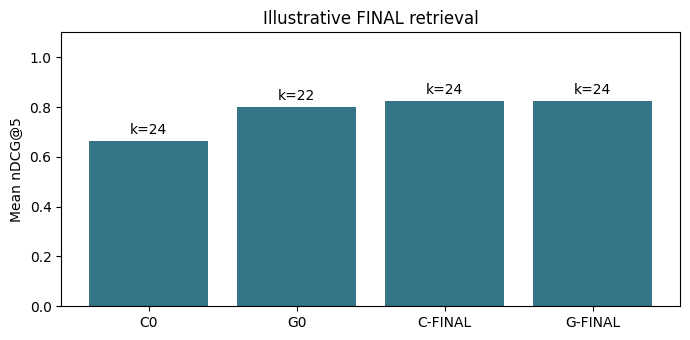

In [13]:
plot_rows = []
for cid in metadata["main_conditions_by_scope"]["FINAL"]:
    values = [
        row["value"]
        for row in outcomes
        if row["scope"] == "FINAL"
        and row["condition_id"] == cid
        and row["metric"] == "ndcg_at_5"
        and row["status"] == "valid"
    ]
    if len(values) >= config.MIN_AGGREGATE_CASES:
        plot_rows.append((cid, sum(values) / len(values), len(values)))
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(
    [row[0] for row in plot_rows], [row[1] for row in plot_rows], color="#367588"
)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Mean nDCG@5")
ax.set_title(f"{metadata['dataset_kind'].capitalize()} FINAL retrieval")
ax.bar_label(bars, labels=[f"k={row[2]}" for row in plot_rows], padding=3)
fig.tight_layout()
display(fig)
plt.close(fig)

## Scientific interpretation and recorded limits

FINAL is an outcome-informed combination without an independent holdout or an
interaction estimate. Shared evidence creates dependencies between questions;
component resampling is a sensitivity analysis, not independent corpus replication.
Missing retrieval positions and outcome-specific NA remain visible. Graph size,
support, citation credit and answer quality describe different surfaces.

Baseline faithfulness was assessed against complete native contexts post hoc,
while earlier accepted variant grades were retained. That assessment asymmetry
belongs to the reported limits. Genuine User uses a separate reference basis and
nominal categories. Question-naturalness paired testing was not executed; the
language revision is part of the benchmark, with no naturalness-change estimate.

Mechanism diagnosis follows Required Fact → available evidence → native context
→ answer/citation → accepted outcome. Observations distinguish directly supported,
plausible and unresolved links. They do not establish a causal explanation.
The evaluation notebooks retain the relevant inputs for this inspection; no new
mechanism quality score is constructed.

## Save the result calculations and figure

Saved output binds its source manifest and full pair memberships. Accepted private
input/output remains under ignored `local/`. After relocating stored artefacts,
verify required files and repeat the relevant result checks.

In [14]:
assert output_dir.resolve().is_relative_to(Path("../local").resolve())
output_dir.mkdir(parents=True, exist_ok=True)
result = {
    "dataset_kind": metadata["dataset_kind"],
    "input_manifest_sha256": hashlib.sha256(
        (data_dir / "manifest.json").read_bytes()
    ).hexdigest(),
    "contrasts": contrasts,
    "gap_shifts": gaps,
    "numeric_figure_data": plot_rows,
    "graph_inventory": inventory,
    "claim_status": "descriptive",
}
if public_rfc_baseline is not None:
    result["public_rfc_baseline"] = public_rfc_baseline
(output_dir / "reported_analysis.json").write_text(
    json.dumps(result, ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
)
fig.savefig(output_dir / "final_retrieval.png", dpi=150, bbox_inches="tight")
print(
    {
        "output": "reported_analysis.json",
        "figure": "final_retrieval.png",
        "model_requests": 0,
    }
)
write_analysis_manifest(
    output_dir,
    data_dir / "manifest.json",
    {
        "reported_analysis": "reported_analysis.json",
        "numeric_figure": "final_retrieval.png",
    },
)


{'output': 'reported_analysis.json', 'figure': 'final_retrieval.png', 'model_requests': 0}


{'schema_version': 'evaluation-outputs-v1',
 'input_manifest_sha256': '4e5bcd07361c4937ab889f1d820febf8958e3ef4bd6ad6c17f4b5f5fc2e4e566',
 'artifacts': {'reported_analysis': {'path': 'reported_analysis.json',
   'sha256': '713ed489eebd83582ce735b178b8f52349a6f092b485efdef7a1d6129d3482be'},
  'numeric_figure': {'path': 'final_retrieval.png',
   'sha256': '50c8ce1575591122759582be5eefdd81d808579ce70fffc9be54711bdd12f9b2'}}}